In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
processed = Path("../data/processed")

fund_master = pd.read_csv(processed/"processed_fund_master.csv")
nav = pd.read_csv(processed/"processed_nav_history.csv")
aum = pd.read_csv(processed/"processed_aum_by_fund_house.csv")
sip = pd.read_csv(processed/"processed_monthly_sip_inflow.csv")
category = pd.read_csv(processed/"processed_category_inflow.csv")
folio = pd.read_csv(processed/"processed_industry_folio_count.csv")
performance = pd.read_csv(processed/"processed_scheme_performance.csv")
transactions = pd.read_csv(processed/"processed_investor_transactions.csv")
holdings = pd.read_csv(processed/"processed_portfolio_holding.csv")
benchmark = pd.read_csv(processed/"processed_benchmark_indice.csv")

#adding scheme names to respective dataframes
nav = pd.merge(nav,fund_master[['amfi_code','scheme_name']],on='amfi_code',how='left')
nav['legend'] = nav['scheme_name'] + ' (' + nav['amfi_code'].astype(str) + ')'
transactions = pd.merge(transactions,fund_master[['amfi_code','scheme_name']],on='amfi_code',how='left')
transactions['legend'] = transactions['scheme_name'] + ' (' + transactions['amfi_code'].astype(str) + ')'
holdings = pd.merge(holdings,fund_master[['amfi_code','scheme_name']],on='amfi_code',how='left')
holdings['legend'] = holdings['scheme_name'] + ' (' + holdings['amfi_code'].astype(str) + ')'


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2500721587.py, line 15)

In [11]:
datasets = {
    "fund_master": fund_master,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)
    display(df.head())


fund_master
(40, 15)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100025,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,Regular,2002-06-25,CRISIL Short Term Bond Index,0.56,0.5,500,1000,Anil Bamboli,Low,DC02
2,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02
3,101206,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01
4,101207,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,500,1000,Mircea Ciobanu,Very High,EC03



nav
(46000, 4)


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth



aum
(90, 5)


...

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Axis Midcap Fund - Regular - Growth



holdings
(322, 9)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name
0,100016,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,11.53,398.60,2074.55,2025-12-31,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,ICICIBANK,ICICI Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,WIPRO,Wipro Ltd,IT,25.90,552.43,579.31,2025-12-31,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,NTPC,NTPC Ltd,Utilities,5.61,1102.98,6325.90,2025-12-31,HDFC Top 100 Fund - Regular Plan - Growth



benchmark
(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-03,CRISIL_LIQUID,2281.51
2,2022-01-03,NIFTY_MIDCAP150,9721.79
3,2022-01-03,CRISIL_GILT,1451.06
4,2022-01-03,NIFTY100,17778.24


In [12]:
nav['date'] = pd.to_datetime(nav['date'])
fig = px.line(nav, x='date', y='nav', color='scheme_name', title='Daily NAV Trends (2022-2026)')
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.2, annotation_text='2023 Bull Run')
fig.add_vrect(x0='2024-01-01', x1='2024-06-30', fillcolor='red', opacity=0.2, annotation_text='2024 Market Correction')
fig.write_image("../reports/eda_charts/nav_trend.png")
fig.show()

Most mutual fund schemes exhibited sustained NAV appreciation during 2023, indicating a broad market bull phase.

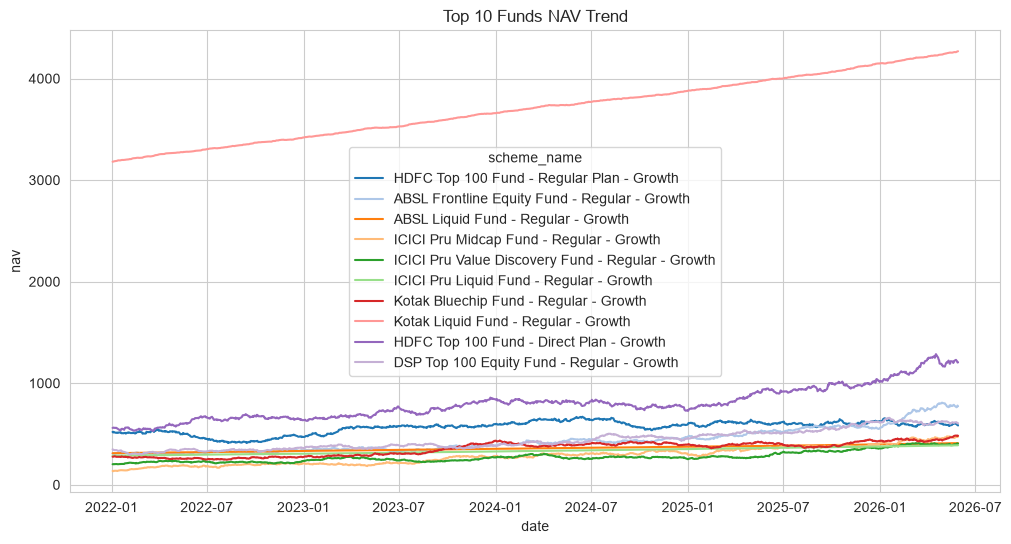

In [30]:
top_funds = nav.groupby('amfi_code')['nav'].mean().nlargest(10).index
sample = nav[nav['amfi_code'].isin(top_funds)]
sns.lineplot(data=sample, x='date', y='nav', hue='scheme_name', palette='tab20')
plt.title("Top 10 Funds NAV Trend")
plt.savefig("../reports/eda_charts/top10_nav.png", dpi=300)
plt.show()

Top-performing schemes demonstrated relatively stable long-term NAV growth trajectories with limited drawdowns.

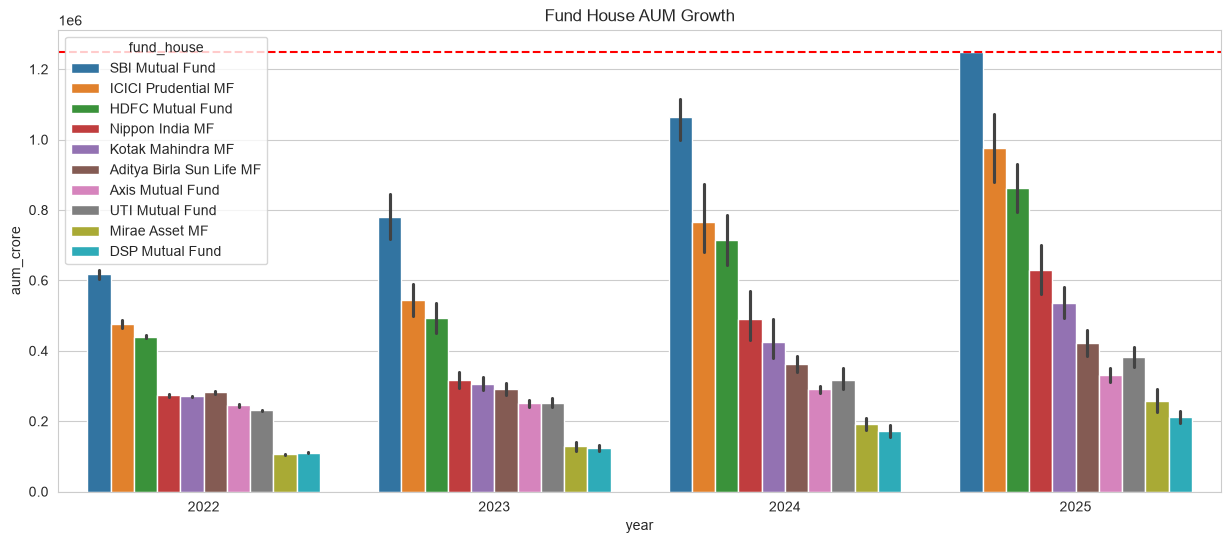

In [14]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year
plt.figure(figsize=(15,6))
sns.barplot(data=aum, x='year', y='aum_crore', hue='fund_house')
plt.axhline(1250000, color='red', linestyle='--')
plt.title("Fund House AUM Growth")
plt.savefig("../reports/eda_charts/aum_growth.png", dpi=300)
plt.show()

SBI Mutual Fund consistently maintained the highest AUM across all years.

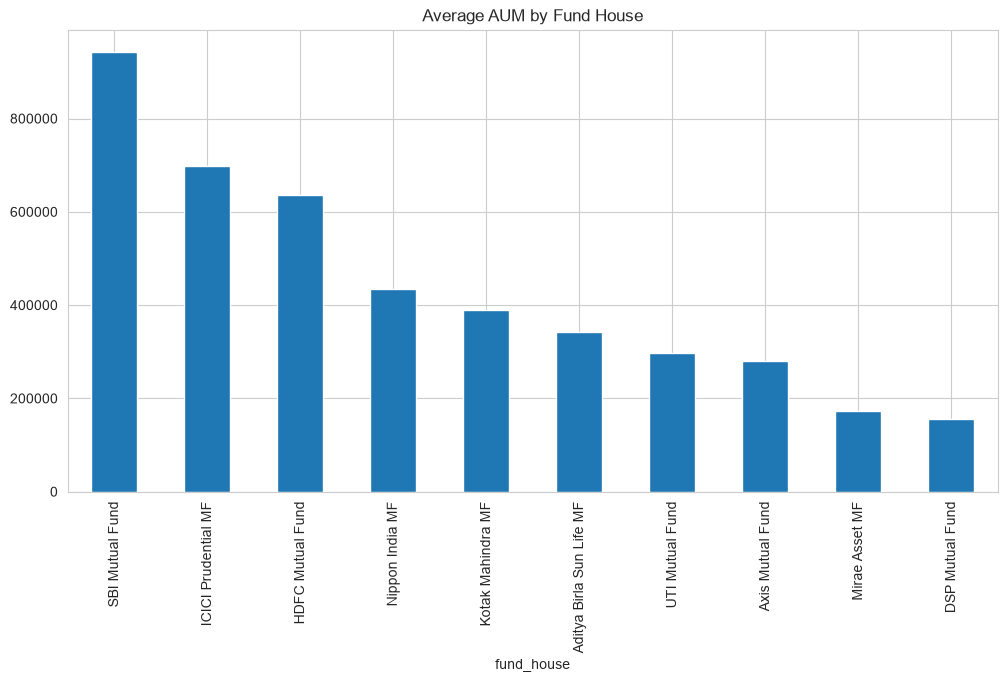

In [15]:
top_aum = aum.groupby('fund_house')['aum_crore'].mean().sort_values(ascending=False)
top_aum.plot.bar()
plt.title("Average AUM by Fund House")
plt.savefig("../reports/eda_charts/aum_avg.png", dpi=300)
plt.show()

AUM concentration remained skewed toward a few large fund houses.

In [16]:
sip['month'] = pd.to_datetime(sip['month'])
fig = px.line(sip, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows')
fig.add_annotation(x='2025-12-01', y=31002, text='₹31,002 Cr ATH')
fig.write_image("../reports/eda_charts/sip_trend.png")
fig.show()

SIP inflows showed strong growth from 2022 to 2025.

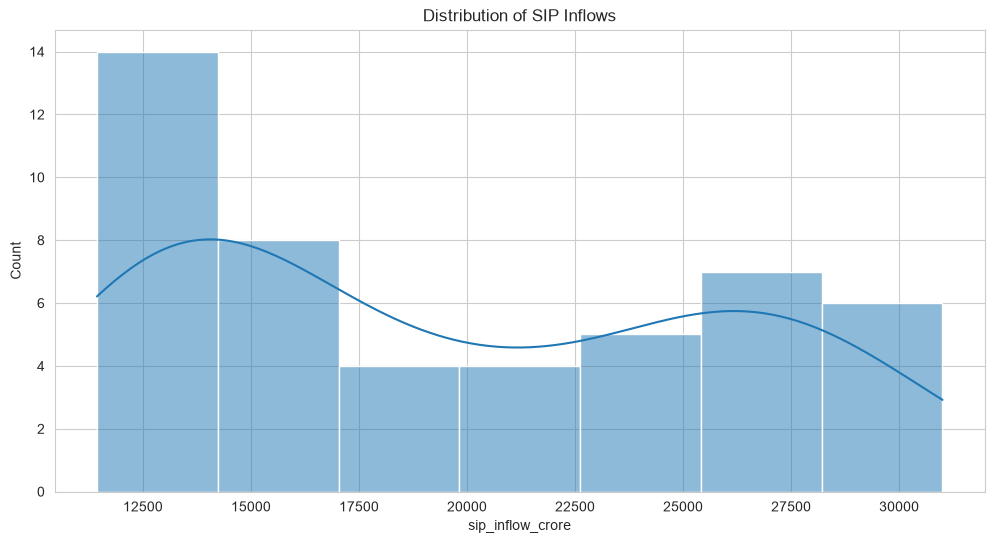

In [17]:
sns.histplot(sip['sip_inflow_crore'], kde=True)
plt.title("Distribution of SIP Inflows")
plt.savefig("../reports/eda_charts/sip_distribution.png", dpi=300)
plt.show()

Monthly SIP inflows remained concentrated in higher ranges.

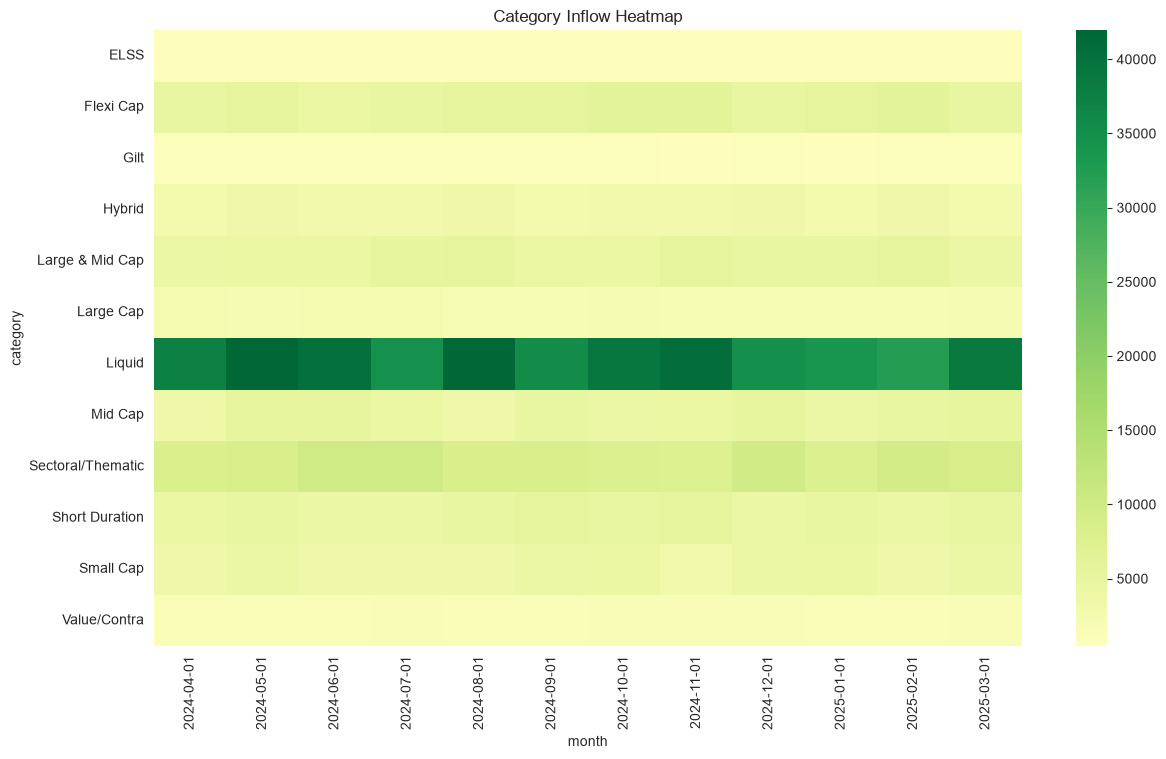

In [18]:
pivot = category.pivot_table(index='category', columns='month', values='net_inflow_crore')
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='RdYlGn', center=0)
plt.title("Category Inflow Heatmap")
plt.savefig("../reports/eda_charts/category_heatmap.png", dpi=300)
plt.show()

Equity-oriented categories attracted consistent inflows.

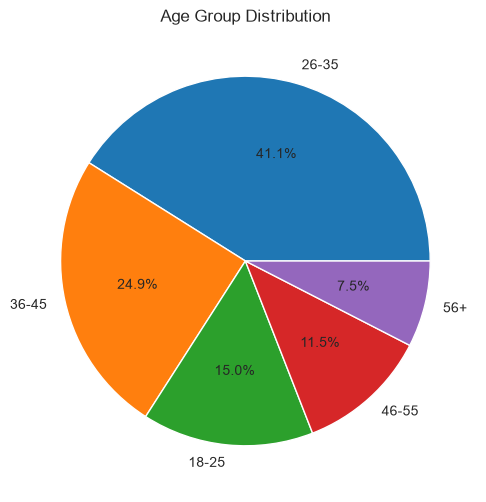

In [19]:
transactions['age_group'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.title("Age Group Distribution")
plt.savefig("../reports/eda_charts/age_distribution.png", dpi=300)
plt.show()

Investors aged 25–40 formed the largest investor segment.

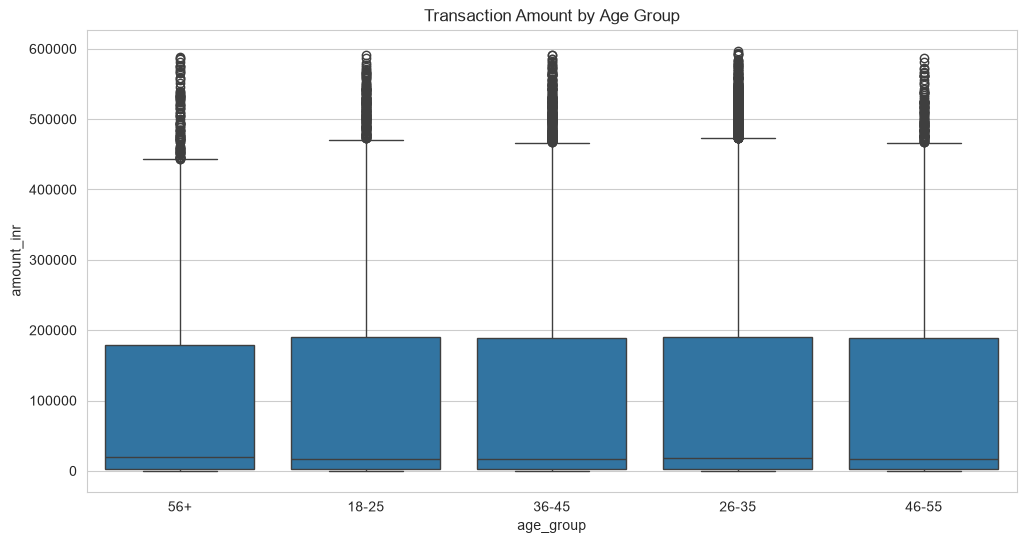

In [20]:
sns.boxplot(data=transactions, x='age_group', y='amount_inr')
plt.title("Transaction Amount by Age Group")
plt.savefig("../reports/eda_charts/amount_age_boxplot.png", dpi=300)
plt.show()

Middle-aged investors recorded higher transaction amounts.

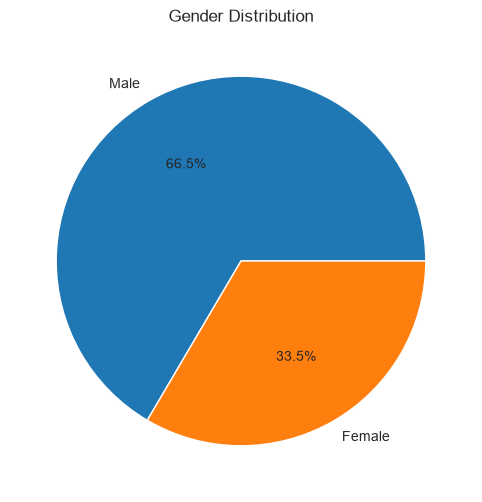

In [21]:
transactions['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.title("Gender Distribution")
plt.savefig("../reports/eda_charts/gender_split.png", dpi=300)
plt.show()

The investor base exhibited a balanced gender composition.

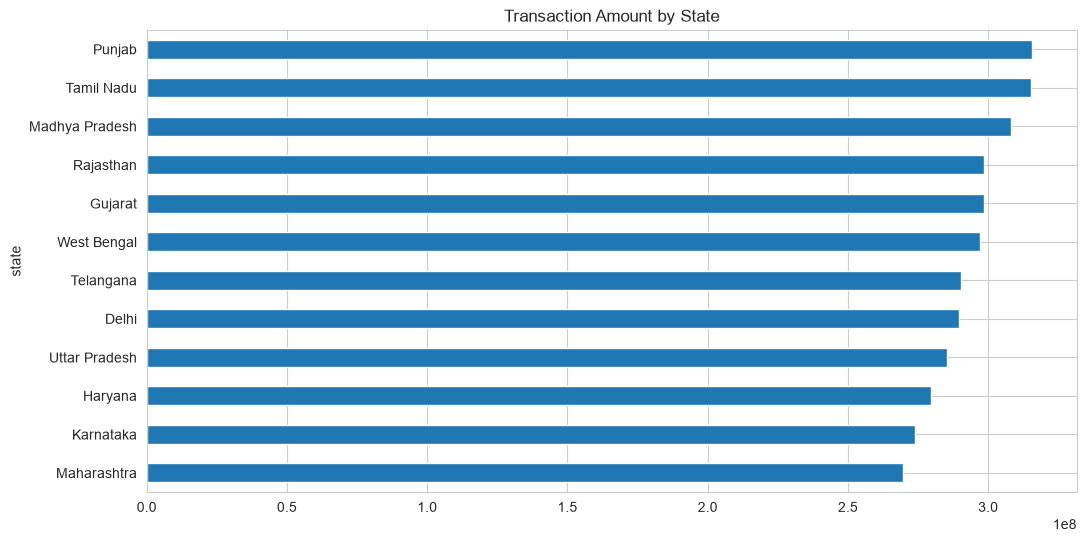

In [22]:
state = transactions.groupby('state')['amount_inr'].sum()
state.sort_values().plot.barh()
plt.title("Transaction Amount by State")
plt.savefig("../reports/eda_charts/state_distribution.png", dpi=300)
plt.show()

Investment activity was concentrated in a few states.

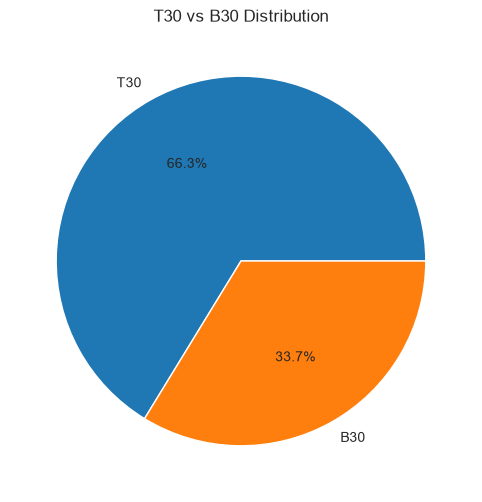

In [23]:
transactions['city_tier'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.title("T30 vs B30 Distribution")
plt.savefig("../reports/eda_charts/t30_b30.png", dpi=300)
plt.show()

T30 cities contributed a larger investment share than B30 cities.

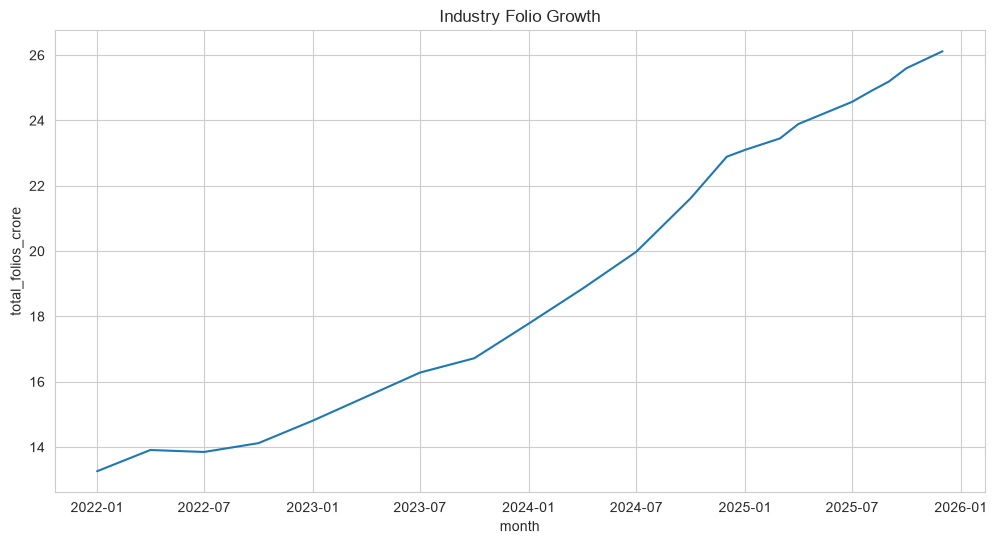

In [24]:
folio['month'] = pd.to_datetime(folio['month'])
sns.lineplot(data=folio, x='month', y='total_folios_crore')
plt.title("Industry Folio Growth")
plt.savefig("../reports/eda_charts/folio_growth.png", dpi=300)
plt.show()

Industry folio counts nearly doubled during the study period.

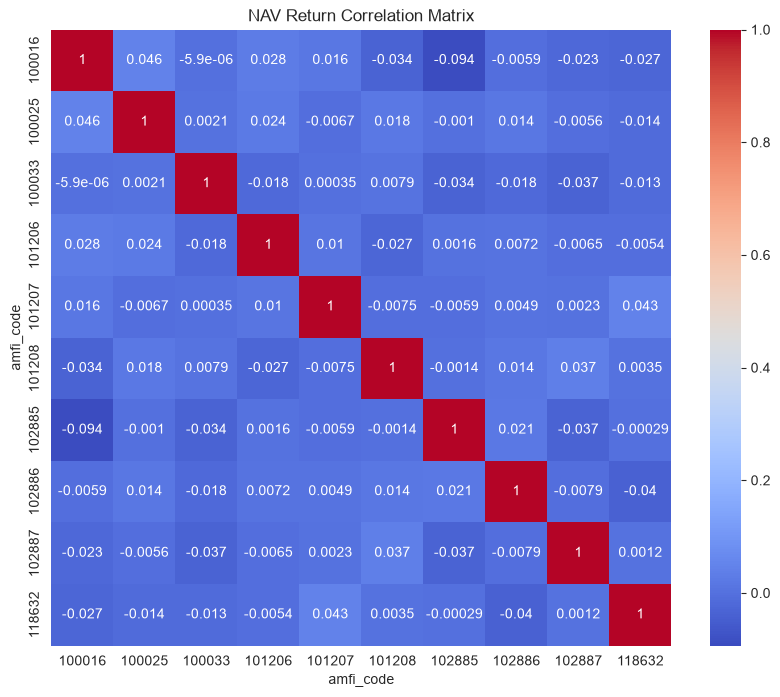

In [25]:
selected = nav[nav['amfi_code'].isin(nav['amfi_code'].unique()[:10])]
pivot = selected.pivot(index='date', columns='amfi_code', values='nav')
returns = pivot.pct_change()
corr = returns.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("NAV Return Correlation Matrix")
plt.savefig("../reports/eda_charts/correlation_matrix.png", dpi=300)
plt.show()

Daily NAV returns across funds exhibited strong positive correlations.

In [26]:
sector = holdings.groupby('sector')['weight_pct'].sum()
fig = px.pie(values=sector.values, names=sector.index, hole=0.5, title='Sector Allocation')
fig.write_image("../reports/eda_charts/sector_allocation.png")
fig.show()

Financial and IT sectors dominated portfolio allocations.

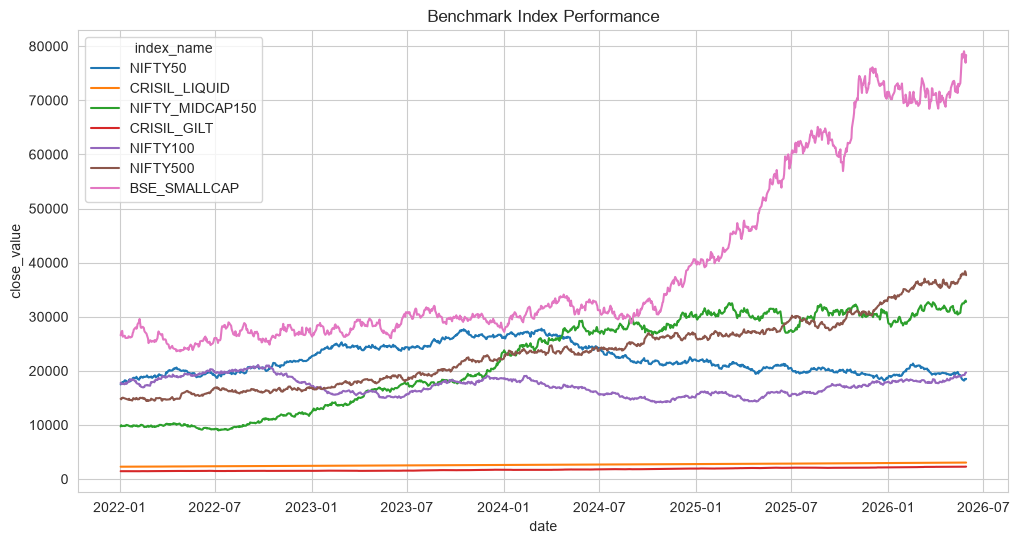

In [27]:
benchmark['date'] = pd.to_datetime(benchmark['date'])
sns.lineplot(data=benchmark, x='date', y='close_value', hue='index_name')
plt.title("Benchmark Index Performance")
plt.savefig("../reports/eda_charts/benchmark_trend.png", dpi=300)
plt.show()

Benchmark indices showed long-term upward momentum.

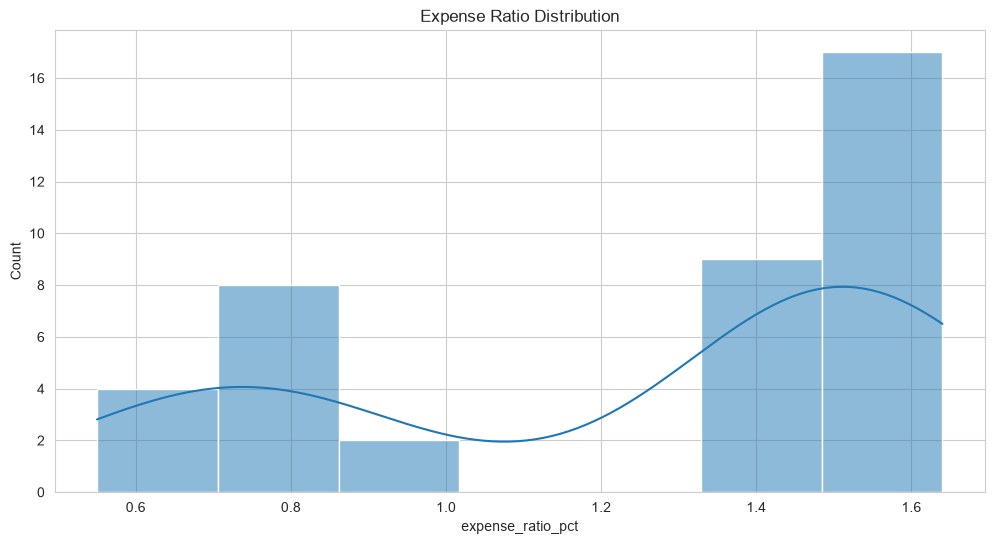

In [28]:
sns.histplot(performance['expense_ratio_pct'], kde=True)
plt.title("Expense Ratio Distribution")
plt.savefig("../reports/eda_charts/expense_ratio_distribution.png", dpi=300)
plt.show()

Most schemes maintained expense ratios below 2%.

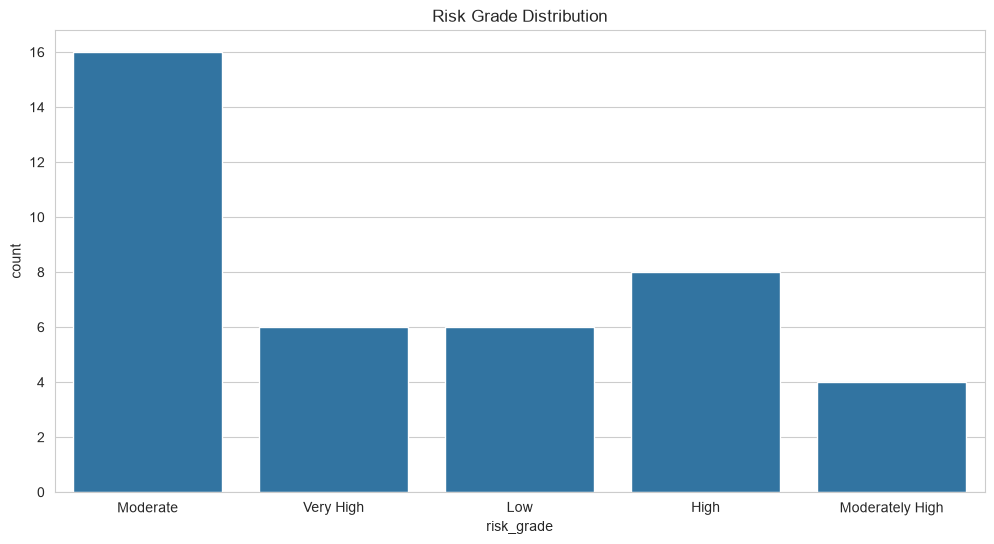

In [29]:
sns.countplot(data=performance, x='risk_grade')
plt.title("Risk Grade Distribution")
plt.savefig("../reports/eda_charts/risk_grade_distribution.png", dpi=300)
plt.show()

A majority of schemes were concentrated in moderate to high-risk categories.